In [1]:
from google.colab import files
uploaded = files.upload()

Saving smart_city_complaints.csv to smart_city_complaints.csv


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('smart_city_complaints.csv')

# Dataset info
print(df.shape)
print(df.info())

# Missing values
print(df.isnull().sum())

# Duplicate values
print("Duplicates:", df.duplicated().sum())

# Date conversion
df['Complaint_Date'] = pd.to_datetime(df['Complaint_Date'])
df['Resolved_Date'] = pd.to_datetime(df['Resolved_Date'])

# Fill missing delay for unresolved complaints
df['Resolution_Delay_Days'] = df['Resolution_Delay_Days'].fillna(0)

# Derived variable
df['Is_Resolved'] = np.where(df['Status']=='Resolved',1,0)

df.head()

(2000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Complaint_ID                2000 non-null   object 
 1   Complaint_Date              2000 non-null   object 
 2   Resolved_Date               1291 non-null   object 
 3   Zone                        2000 non-null   object 
 4   Category                    2000 non-null   object 
 5   Department                  2000 non-null   object 
 6   Priority                    2000 non-null   object 
 7   Priority_Score              2000 non-null   int64  
 8   Status                      2000 non-null   object 
 9   Resolution_Delay_Days       1291 non-null   float64
 10  Citizen_Satisfaction_Score  2000 non-null   float64
 11  Month                       2000 non-null   object 
 12  Quarter                     2000 non-null   object 
 13  Week                  

,Complaint_ID,Complaint_Date,Resolved_Date,Zone,Category,Department,Priority,Priority_Score,Status,Resolution_Delay_Days,Citizen_Satisfaction_Score,Month,Quarter,Week,Is_Resolved
0,CMP00001,2024-11-23,2024-12-04,East Zone,Drainage Problem,Drainage Dept,Medium,2,Resolved,11.0,3.4,November,Q4,47,1
1,CMP00002,2024-02-27,NaT,Central Zone,Water Supply,Water Supply Dept,Medium,2,In Progress,0.0,1.9,February,Q1,9,0
2,CMP00003,2024-01-13,2024-01-29,Industrial Zone,Garbage Collection,Sanitation Dept,Low,1,Resolved,16.0,2.0,January,Q1,2,1
3,CMP00004,2024-05-20,2024-05-29,North Zone,Water Supply,Water Supply Dept,Medium,2,Resolved,9.0,2.7,May,Q2,21,1
4,CMP00005,2024-05-05,2024-05-06,Central Zone,Traffic Congestion,Traffic Management Dept,High,3,Resolved,1.0,4.9,May,Q2,18,1


In [3]:
total_complaints = len(df)
print(total_complaints)

2000


In [4]:
resolved_complaints = df[df['Status']=='Resolved'].shape[0]
print(resolved_complaints)

1291


In [5]:
resolution_rate = (resolved_complaints/total_complaints)*100
print(round(resolution_rate,2))

64.55


In [6]:
avg_resolution_time = df['Resolution_Delay_Days'].mean()
print(round(avg_resolution_time,2))

5.15


In [7]:
high_priority = df[df['Priority']=='High'].shape[0]
print(high_priority)

486


In [8]:
avg_satisfaction = df['Citizen_Satisfaction_Score'].mean()
print(round(avg_satisfaction,2))

2.75


In [9]:
hotspot = df['Zone'].value_counts()
print(hotspot)

Zone
West Zone          270
North-East Zone    263
North Zone         257
Central Zone       256
South Zone         248
Industrial Zone    242
South-West Zone    242
East Zone          222
Name: count, dtype: int64


In [10]:
dept_performance = df.groupby('Department')['Resolution_Delay_Days'].mean()
print(dept_performance)

Department
Drainage Dept              5.353571
Electricity Dept           5.512195
Police Dept                4.923077
Public Works Dept          4.915309
Sanitation Dept            4.855124
Traffic Management Dept    5.010000
Water Supply Dept          5.511111
Name: Resolution_Delay_Days, dtype: float64


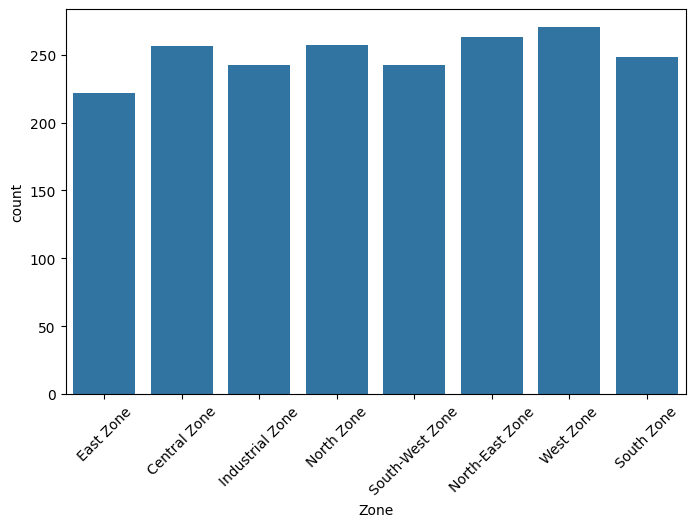

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df,x='Zone')
plt.xticks(rotation=45)
plt.show()

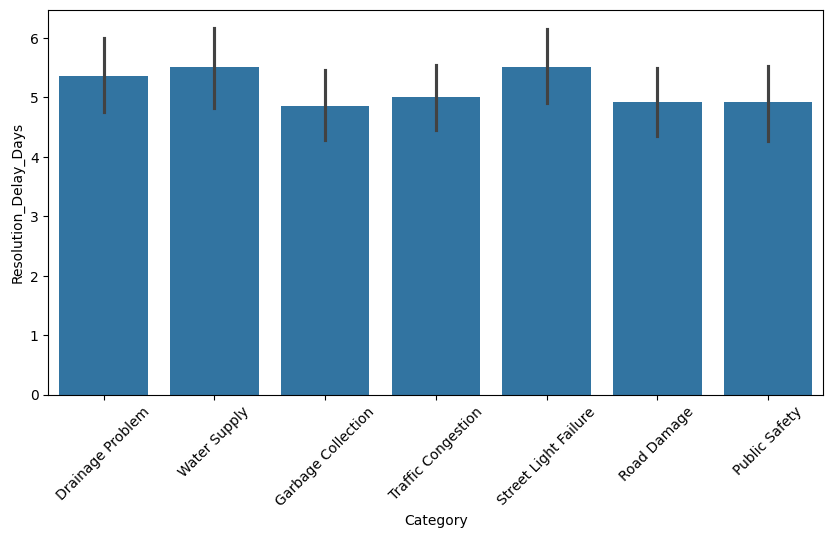

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x='Category',
    y='Resolution_Delay_Days'
)
plt.xticks(rotation=45)
plt.show()

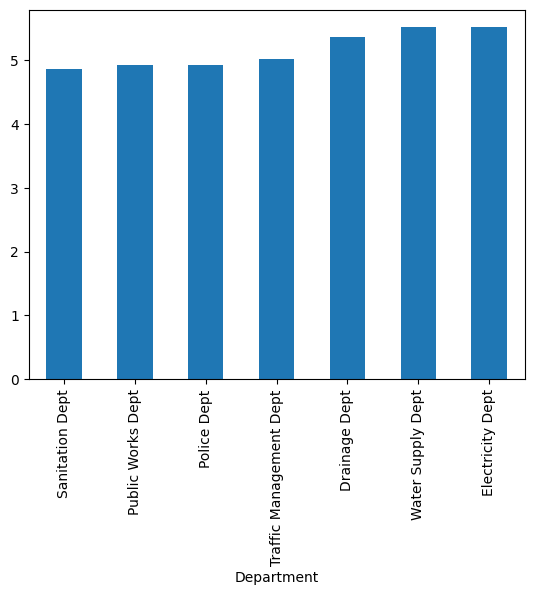

In [13]:
dept = df.groupby('Department')['Resolution_Delay_Days'].mean().sort_values()

dept.plot(kind='bar')
plt.show()

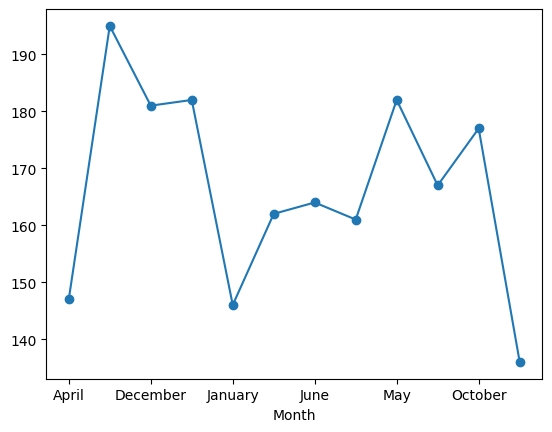

In [14]:
trend = df.groupby('Month').size()

trend.plot(kind='line',marker='o')
plt.show()

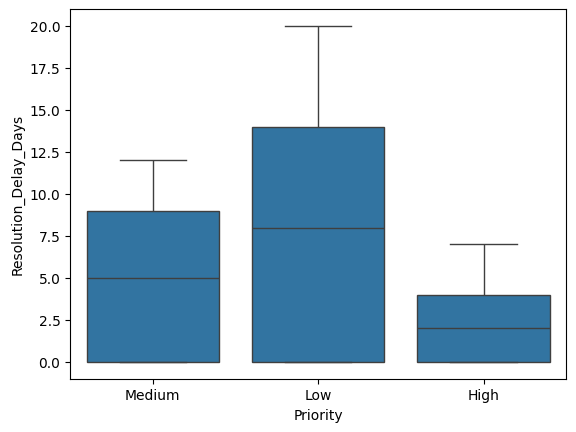

In [15]:
sns.boxplot(
    data=df,
    x='Priority',
    y='Resolution_Delay_Days'
)
plt.show()

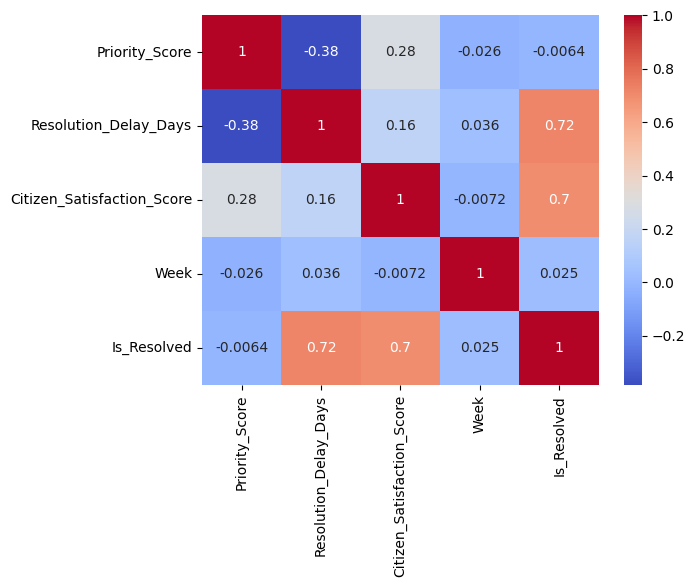

In [16]:
numeric_df = df.select_dtypes(include='number')

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [17]:
print("Total Complaints:",total_complaints)
print("Resolution Rate:",resolution_rate)
print("Average Satisfaction:",avg_satisfaction)
print("Average Resolution Time:",avg_resolution_time)

Total Complaints: 2000
Resolution Rate: 64.55
Average Satisfaction: 2.7506
Average Resolution Time: 5.1495
